In [1]:
import optic as oc
import cupy as cp
import numpy as np

print(f"Biblioteca OptiCommPy carregada de: {oc.__file__}")
print(f"GPU disponível: {cp.cuda.runtime.getDeviceCount() > 0}")

Biblioteca OptiCommPy carregada de: /home/marcos/PIBITI/OptiCommPy/optic/__init__.py
GPU disponível: True


In [2]:
import numpy as np
from scipy.fft import fft, fftshift, fftfreq
import matplotlib.pyplot as plt
import sympy as sp
import pandas as pd

#!pip install OptiCommPy
from IPython.display import display, Math, Latex
from optic.comm.modulation import modulateGray, demodulateGray, grayMapping
from optic.dsp.core import firFilter, signalPower, pulseShape, upsample, pnorm
from optic.utils import parameters, dBm2W
from optic.models.devices import mzm, photodiode
from optic.plot import eyediagram

In [25]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
import matplotlib as mpl

figsize(17, 2)
mpl.rcParams['agg.path.chunksize'] = 10000

## Sumário
---
- [Introdução a comunicações ópticas](#introdução-a-comunicações-ópticas)
- [Tipos de transmissores](#tipos-de-transmissores)
- [Representações para a portadora óptica](#representações-para-a-portadora-óptica)
- [Modulações de Mach-Zehnder](#modulações-de-Mach-Zehnder)
- [Gerando sinais OOK](gerando-sinais-ook)
- [Gerando sinais M-PAM](gerando-sinais-m-pam)


## __Introdução a comunicações ópticas__ <a id="Introdução a comunicações ópticas"></a>
---

Qualquer sistema que emite a luz para transformar informações pode ser considerado um sistema de conunicações ópticas. O sucesso de um sistema de comunicações ópticas está relacionada à capacidade de transmitir grandes volumes de tráfego por longas distâncias. Redes de comunicação possuem sua hierarquia que sustenta a distribuição de internet e uma capacidade máxima de operação. Com o surgimento de várias plataformas e serviços a demanda cresce muito e ao atingir a capacidade máxima a rede entra em colapso. Para solucionar esse problema novas tecnologias devem ser implementadas.

Em comunicações ópticas usamos ondas com frequências que variam de $10^{12} Hz$ até $luz \ visível$, as frequências acima disso são muito prejudiciais a saúde e não é interessante. Um fenomêno interessnte para a fibra óptica é a __refração total__, que ao jogar um feixe de luz a um determinado ângulo ele fica confinado e é refletido toda vez que atingir a parede da guia.

<center><img src="https://descomplica-blog-production.s3-sa-east-1.amazonaws.com/2015/09/tir.jpg" width="30%" style="display:inline-block; margin-right:5%;"/>
<img src="http://descomplica-blog-production.s3-sa-east-1.amazonaws.com/2015/09/r9QOR8Y.jpg" width="55%" style="display:inline-block;"/></center>

$$ \text{Fonte: Descomplica: Aprenda tudo sobre refração da luz!}$$

  - Vantagens de sistemas de cominicações ópticas.
    + larga faixa de frequência com baixa atenuação _(de 4 a 10 THz)_
      $$ \frac{Fibra \ óptica}{Conexão \ 4G} = \frac{4 \ THz}{20 \ MHz} = \frac{4.10^{12}}{20.10^{7}} = 200.000 \ \text{usúarios}$$

    + baixo custos por bit transmitido;
    + Desafios:
      - Aumento da capacidade das redes,
      - eficiência ebergética,
      - capacity crunch.

Na fibra acontece a refração, pois ela funciona como espelhos, assim:
$$\begin{equation}
R_n = \left(\frac{n1 - n2}{n1 + n2}\right) = \left(\frac{na - 1}{na + 1}\right), n_2\text{ = AR = 1}
\end{equation}$$

__Perdas:__ $g = α_{int} + \frac{1}{2L}ln\left(\frac{1}{R1R2}\right) = α_{int} + α_{mir}$

__Fase:__ $V_m = \frac{mc}{2nL}$

### __Tipos de transmissores:__ <a id="Tipos de transmissores"></a>
---

  - Directly-modulated lasers (DML):
    + Muito ruído
  - Externally-modulated lasers (EML):
    + Baixa razão de extinção (≈ 10bB);
    + Alta perda de inserção (≈ 10dB).
  - Mach-Zehnder Modulators (MZMs):
    + Alta razão de extinção (≈ 20bB);
    + Baixa perda de inserção (≈ 5dB);
    + Principio da Interferência controlada por modulação de fase.

Em um sistema de comunicação digital, o transmissor transforma uma sequência de bits em um conjunto de pulsos elétricos, que depois são usados para modular uma portadora óptica. A representação abaixo ilustra esse processo.
<center><img src="https://github.com/Medupl/CoppeliaSim/blob/main/images/Optic/gerador%20de%20sinais%20.png?raw=true" width="50%"/></center>

$$\text{Fonte: Anotações do professor Edson}$$

### __Representações para a portadora óptica__ <a id="Representações para a portadora óptica"></a>
---

O campo elétrico $E(t)$ de uma portadora óptica em onda contínua pode ser descrito matematicamente da seguinte forma:
$$\begin{equation}E(t)=Acos(ω_ct+θ)e\end{equation}$$

Aqui, $A$ representa a amplitude da onda, $ω_c$  é a frequência angular da portadora, $θ$ é a fase inicial e o vetor __e__ representa o vetor de polarização. Essa equação modela a propagação da onda eletromagnética e é fundamental para entender a modulação e transmissão de sinais em sistemas ópticos.




In [4]:
θ, omega_c, A, t = sp.symbols("θ, omega_c, A, t", real = True)
j = sp.I
π = sp.pi
E = A * sp.cos(omega_c * t + θ)
display(Math("E(t) = "+ sp.latex(E)))

E = sp.expand_trig(E)
display(Math("E(t) = "+ sp.latex(E)))

Ai = sp.re(A*sp.exp(j*θ))
Aq = sp.im(A*sp.exp(j*θ))
print("Representação cartesiana:")
display(Math("E(t) = "+ sp.latex(Ai + j*Aq)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Representação cartesiana:


<IPython.core.display.Math object>

### **Modulador de Mach-Zehnder**  
---

<center><img src= "https://github.com/Medupl/CoppeliaSim/blob/main/images/Optic/Modulador%20Mach-zehnder.png?raw=True" width="60%"/></center>

$$\begin{equation}
\begin{bmatrix}
\hat{E_1} \\
\hat{E_2}
\end{bmatrix} =
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & j \\
j & 1
\end{bmatrix}
\begin{bmatrix}
e^{jϕ_1} & 0 \\
0 & e^{jϕ_2}
\end{bmatrix}
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & j \\
j & 1
\end{bmatrix}
\begin{bmatrix}
\hat{E_i} \\
0
\end{bmatrix}
\end{equation}$$

O modulador de Mach-Zehnder é um dispositivo óptico fundamental em sistemas de comunicações coerentes. Ele divide a energia da entrada igualmente entre dois caminhos, cada um recebendo 50% do sinal incidente. Esse comportamento caracteriza sua atenuação de **3 dB**.  

Cada caminho do modulador possui um atraso diferente, o que pode ser descrito por **matrizes unitárias**, garantindo que a energia do sistema seja preservada. O sinal entra por um lado e se propaga por dois "braços", onde ocorre uma modulação por interferência.  

A configuração **push-pull** desse sistema faz com que exista um ponto em comum entre os acoplamentos ópticos. Em cada braço do modulador, aplicamos tensões  $u_1(t)$ e $u_2(t)$, sendo uma positiva e a outra negativa. Esse mecanismo permite controlar a fase do sinal óptico de saída, modulando a intensidade e garantindo um comportamento eficiente na transmissão de dados.

In [5]:
# Definindo símbolos
ϕ, ϕ1, ϕ2 = sp.symbols('ϕ, ϕ1, ϕ2', real=True)
Ai = sp.symbols('A_i', real=True)

# Matriz C
C = 1/sp.sqrt(2) * sp.Matrix([[1, j], [j, 1]])
display(Math('C = ' + sp.latex(C)))

# Matriz M
M = sp.Matrix([[sp.exp(j*ϕ1), 0], [0, sp.exp(j*ϕ2)]])
display(Math('M = ' + sp.latex(M)))

# Operação T (transposta conjugada de C)
T = C*M*C
display(Math('T = ' + sp.latex(T)))

# Vetor Ei
Ei = sp.Matrix([[Ai], [0]])
display(Math(r'\hat{E}_i = ' + sp.latex(Ei)))

# Vetor Saída
E0 = T*Ei
display(Math('\hat{E}_o = ' + sp.latex(E0)))

E0[1].subs({ϕ1:ϕ, ϕ2:-ϕ}).simplify()


<>:23: SyntaxWarning: invalid escape sequence '\h'
<>:23: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_36449/3003348341.py:23: SyntaxWarning: invalid escape sequence '\h'
  display(Math('\hat{E}_o = ' + sp.latex(E0)))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

I*A_i*cos(ϕ)

Assim temos que as expressões podem ser representadas por:

$$\begin{equation}
\frac{\hat{E}_{out}(t)}{\hat{E}_{in}(t)} =
\frac{1}{2}(e^{jϕ(t)} + e^{-jϕ(t)})e^{j\frac{π}{2}}
\end{equation}$$

$$\begin{equation}
ϕ(t) = \frac{1}{2V_r}[u(t) + V_b]π
\end{equation}$$

$$\begin{equation}
A_{out}(t) = A_{in}(t) cos\left(\frac{1}{2V_r}[u(t) + V_b]π\right)
\end{equation}$$

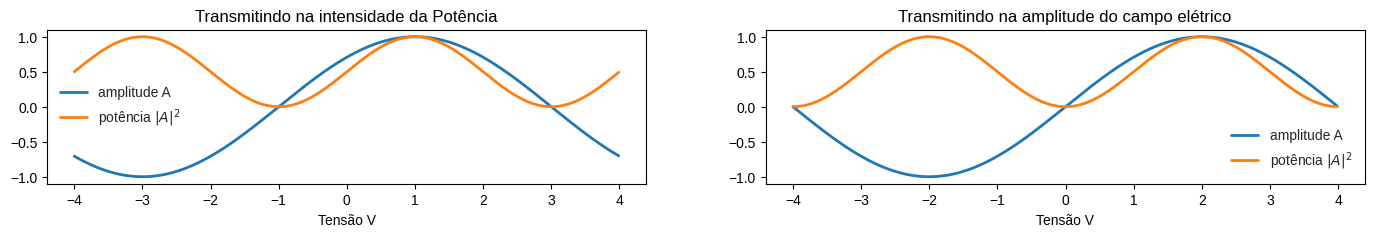

Razão de Extinção (ER) = 30.44522437723423 dB


In [6]:
paramMZM = parameters()
paramMZM.Vpi = 2
paramMZM.Vb = (-paramMZM.Vpi/2)

u = np.arange(-2*paramMZM.Vpi, 2*paramMZM.Vpi, 0.01)        # Gera valores aleatórios entre -2*Vπ e 2*Vπ

Ai = 1
A0 = mzm(Ai, u, paramMZM)

fig, axis = plt.subplots(1, 2, figsize=(17, 2))
plt.style.use("seaborn-v0_8-darkgrid")

axis[0].plot(u, A0, label="amplitude A", linewidth = 2)
axis[0].plot(u, np.abs(A0)**2, label="potência $|A|^2$", linewidth = 2)
axis[0].set_title("Transmitindo na intensidade da Potência")
axis[0].set_xlabel("Tensão V")
axis[0].legend()

paramMZM.Vb = (-paramMZM.Vpi)
A0 = mzm(Ai, u, paramMZM)

axis[1].plot(u, A0, label="amplitude A", linewidth = 2)
axis[1].plot(u, np.abs(A0)**2, label="potência $|A|^2$", linewidth = 2)
axis[1].set_title("Transmitindo na amplitude do campo elétrico")
axis[1].set_xlabel("Tensão V")
axis[1].legend()

plt.show()
P = 10*np.log(np.abs(A0)**2 + 0.05)
print("Razão de Extinção (ER) =", max(P)-min(P), "dB")

### **Razão de extinção**

$$\begin{equation}
ER_{db} = 10 log_{10} \left( \frac{P_1}{P_0} \right)
\end{equation}$$

Quanto maior a razão de extinção melhor, pois o sistema irá separar melhor o que é o bit "1" ou o bit "0".

### **Intervalos de sinalização**

Transmissores digitais transmitem informações com uma base de tempo chamada _intervalo de sinalização_ $Ts$, o inverso é chamado de _taxa de transmissão de símbolos_ $Rs$. A taxa de transmissão de bits do sistema é dado por: $Rb = kRs$

### **teorema de amostragem**

Esse teorema estabelece uma conclusão suficiente para uma taxa de amostragem que permite que uma sequência discreta de amostras capture toda informação.
Considere um sinal $x(t)$ limitado em banda e o espectro de frequência $X(f)$ está contido no intervalo $-B < fa < B$.

Se $fa \ge 2B$, x(t) pode ser perfeitamente reconstruido a partir de suas amostras $x(k)$, pela sequinte equação:
$$\begin{equation}
x(t) = \sum_{k = -∞}^{∞}x(kT_a)sinc\left(\frac{t - kT_a}{T_a}\right)
\end{equation}$$

Os códigos abaixo simulam um sinal contínuo e mostram na prática como a taxa de amostragem afeta a reconstrução do sinal original. A gente começa criando um sinal analógico suave, depois amostra ele em intervalos regulares - é como tirar várias fotos rápidas de um sinal em movimento.Se amostrarmos com uma frequência de amostragem baixa, o sinal reconstruído fica todo distorcido, perdemos detalhes importantes. Mas quando seguimos a regra de Nyquist (amostrar pelo menos no dobro da frequência máxima do sinal), conseguimos recuperar quase perfeitamente o sinal original. Os gráficos mostram exatamente isso - o sinal original, os pontos de amostragem e como fica o sinal depois da reconstrução. Quanto mais amostras, mais fiel fica a reprodução do sinal!

In [7]:
def sincInterp(x, fa):

    fa_sinc = 32*fa
    Ta_sinc = 1/fa_sinc
    Ta = 1/fa
    t = np.arange(0, x.size*32)*Ta_sinc

    y = upsample(x,32)
    y[y==0] = np.nan

    x_sum = 0
    for k in range(0, x.size):
        xk_interp = x[k]*np.sinc((t-k*Ta)/Ta)
        x_sum += xk_interp

    return x_sum, t

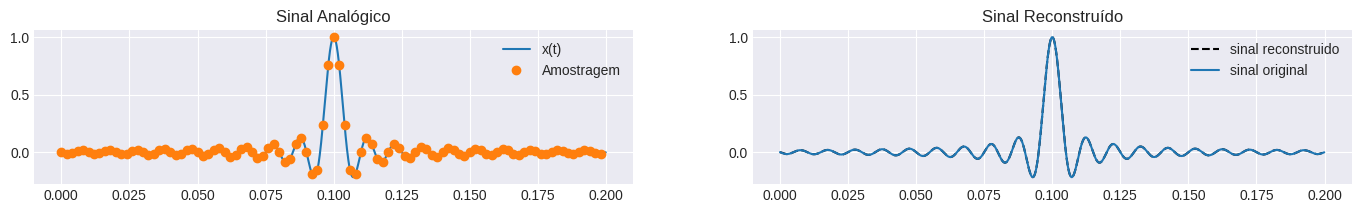

In [8]:
Fa = 500                      # frequência de amostragem
B = 100                       # banda do sinal
Ta = 1/Fa                     # Taxa de amostragem

t = np.arange(0, 0.2, Ta/16)  #duração do sinal
d = t.size/2                  #deixa o sinal simetrico
x = np.sinc(2*B*(t-d*(Ta/16)))#cria o sinal sinc

# Fazendo a amostragem do sinal, deixando com menos pontos.
xa = x[::16]
ta = t[::16]

plt.style.use('seaborn-v0_8-darkgrid')
fig, axis = plt.subplots(1, 2, figsize=(17, 2))
axis[0].plot(t, x, label = "x(t)")
axis[0].plot(ta, xa, 'o', label = "Amostragem")
axis[0].set_title("Sinal Analógico")
axis[0].legend()

x_int, t_int = sincInterp(xa, Fa)
axis[1].plot(t_int, x_int, "--k", label="sinal reconstruido")
axis[1].plot(t,x, label="sinal original")
axis[1].set_title("Sinal Reconstruído")
axis[1].legend()

plt.show()

Para visualizar os exemplos clique no link: [Códigos de Comunicações Ópticas](https://github.com/Medupl/PIBITI/blob/main/Capacitacao/Comunicacoes-Opticas/Codigos_de_C_O.ipynb)

### Chaveamento por deslocamento de amplitude ASK/PAM
---

No código abaixo, implementamos um transmissor digital que gera uma sequência de bits aleatória, converte esses bits em sinais discretos usando modulação por amplitude (ASK/PAM - onde 0 é mapeado para -1V e 1 para +1V no caso binário), e finalmente formata esses símbolos através de um pulso retangular ideal para criar o sinal elétrico transmitido, demonstrando na prática os princípios do chaveamento por deslocamento de amplitude, técnica fundamental em comunicações digitais que codifica informação na variação da amplitude do sinal.

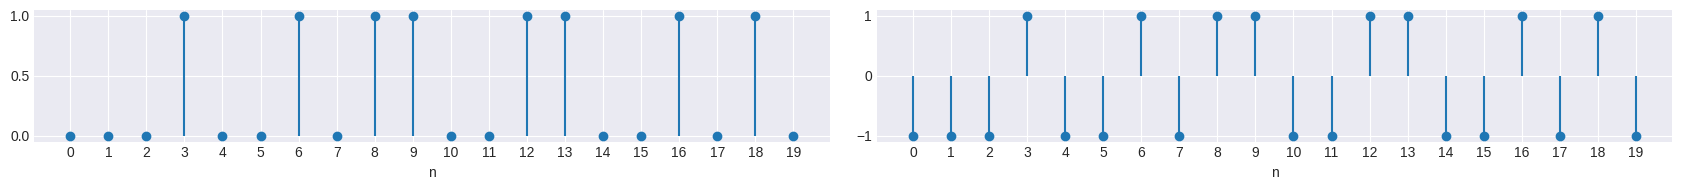

In [9]:
Rs = 10e9                                       # Taxa de simbolos
Ts = 1/Rs                                       # Periodo de simbolos

bits = np.random.randint(2, size=20)
n = np.arange(0,bits.size)

#mapeia bits para simbolos binarios para gerar sinais eletricos.
symb = 2*bits-1

fig, axis = plt.subplots(1, 2, figsize=(17, 2))
plt.style.use("seaborn-v0_8-darkgrid")

axis[0].stem(bits, basefmt=" ")
axis[0].set_xlabel("n")
axis[0].set_xticks(n)

axis[1].stem(symb, basefmt=" ")
axis[1].set_xlabel("n")
axis[1].set_xticks(n)

plt.tight_layout()
plt.show()

### Gerando sinais OOK
---

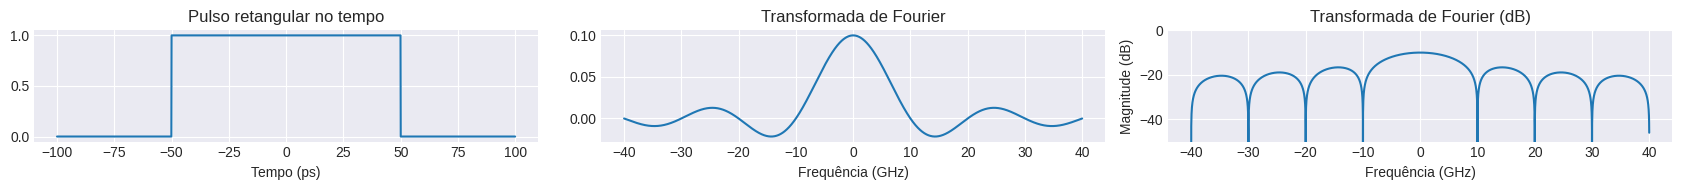

In [10]:
# Definições simbólicas
Ts = sp.symbols('T_s', real=True, positive=True)
t, f = sp.symbols('t, f', real=True)

#Função retangular e sua transformada
def rect(t, a):
    return sp.Heaviside(t + a) - sp.Heaviside(t - a)

p = rect(t, Ts/2)
P = sp.fourier_transform(p, t, f)

# Substituição numérica
Rs = 10e9                                       # Taxa de simbolos
Ts_num = 1/(Rs/1e12)                            # Período em picossegundos
t_vals = np.arange(-1, 1, 0.001)*(1/(Rs/1e12))
p_num = sp.lambdify(t, p.subs(Ts, Ts_num), 'numpy')(t_vals)

f_vals = np.arange(-4, 4, 0.001)*(Rs/1e9)
P_num = sp.lambdify(f, P.subs(Ts, 1/(Rs/1e9)), 'numpy')(f_vals)

P_dB = 10 * np.log10(np.abs(P_num) + 1e-22)

# 4. Plot do pulso no tempo
plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(1, 3, figsize=(17, 2))

ax[0].plot(t_vals, p_num)
ax[0].set_title("Pulso retangular no tempo")
ax[0].set_xlabel("Tempo (ps)")

ax[1].plot(f_vals,(P_num))
ax[1].set_title("Transformada de Fourier")
ax[1].set_xlabel("Frequência (GHz)")

ax[2].plot(f_vals, P_dB)
ax[2].set_title("Transformada de Fourier (dB)")
ax[2].set_xlabel("Frequência (GHz)")
ax[2].set_ylabel("Magnitude (dB)")
ax[2].set_ylim(-50, 0)

plt.tight_layout()
plt.show()

In [11]:
# parâmetros da simulação

SpS = 128                                       # Parametros de amostra por simbolo
Rs = 10e9                                       # Taxa de simbolos
Ts = 1/Rs                                       # Periodo de simbolos
Fa = 1/(Ts/SpS)                                 # fr de amostragem
Ta = 1/Fa                                       # per de amostragem                                                                 

paramPulse              = parameters()
paramPulse.pulseType    = "rect"
paramPulse.SpS          = SpS

# pulso retangular ideal
pulse = pulseShape(paramPulse)
pulse = pnorm(pulse)

In [12]:
# Aumenta a taxa de amostragem, acrescentando zeros.
symbolsUp = upsample(symb,SpS)

# Formatação pelo pulso retangular
sigft = firFilter(pulse, symbolsUp)
sigft = sigft.real
t1 = np.arange(0, sigft.size)*(Ta/1e-12)

#ajustando os ponto de amostragem
symbolsUp = upsample(symb,SpS).astype(np.float64)
symbolsUp[symbolsUp==0] = np.nan
t2 = (0.5 + np.arange(0, bits.size))*(Ts/1e-12)

#Modulação optica
paramMZM = parameters()
paramMZM.Vpi = 2
paramMZM.Vb = (-paramMZM.Vpi/2)

#Definindo a potência da portadora de entrada:
P0 = 100e-3
Ai = np.sqrt(P0)
sigft0 = mzm(Ai, sigft, paramMZM)
t3 = np.arange(0, sigft0.size)*(Ta/1e-12)

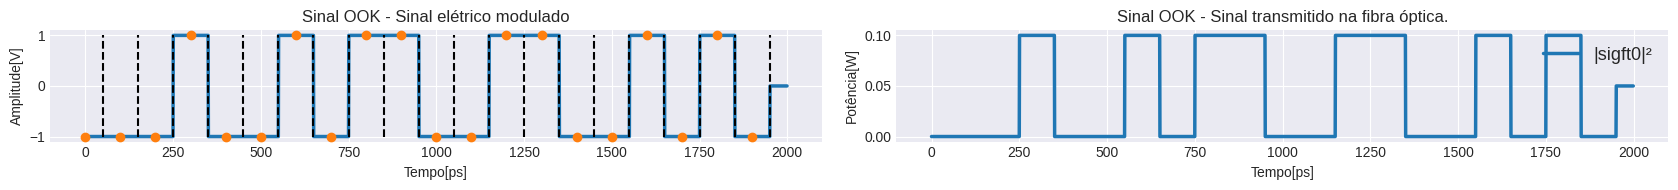

In [13]:
plt.style.use("seaborn-v0_8-darkgrid")
fig, axis = plt.subplots(1, 2, figsize=(17, 2))

axis[0].plot(t1, sigft, "-", linewidth = 2.5)
axis[0].plot(t1, symbolsUp, "o", linewidth = 2.5)
axis[0].vlines(t2, -1, 1, linestyles='dashed', color = 'k')
axis[0].set_xlabel("Tempo[ps]")
axis[0].set_ylabel("Amplitude[V]")
axis[0].set_title("Sinal OOK - Sinal elétrico modulado")

axis[1].plot(t3, np.abs(sigft0)**2, linewidth = 2.5, label = "|sigft0|²")
axis[1].set_xlabel("Tempo[ps]")
axis[1].set_ylabel("Potência[W]")
axis[1].set_title("Sinal OOK - Sinal transmitido na fibra óptica.")
axis[1].legend(loc="best", fontsize = 13)

plt.tight_layout()
plt.show()

Processos usados no plot acima:

  - Geração da sequência de bits, que representa a informação digital a ser transmitida.

  - Mapeamento dos bits para símbolos elétricos.

  - Upsampling dos símbolos, aumentando a taxa de amostragem e preparando o sinal para a filtragem.

  - Formatação do pulso, utilizando um pulso retangular para moldar os símbolos no tempo.

  - Plotagem do sinal elétrico, que representa o que será aplicado ao modulador.

  - Modulação óptica com MZM, onde o sinal elétrico modula a potência da luz contínua (CW) — simulando a etapa de transmissão óptica.

  - Plotagem do sinal óptico após o MZM, representado em termos de potência óptica.


Para visualizar outros exemplos clique no link: [Códigos de Comunicações Ópticas](https://github.com/Medupl/PIBITI/blob/main/Capacitacao/Comunicacoes-Opticas/Codigos_de_C_O.ipynb)

### Exmplos de densidade espectral de potência
---

Analisar a densidade espectral de potência (PSD) é importante pois conseguimos perceber qual faixa de frequência o sinal ocupa, podemos medir a largura de banda efetiva, comparar a eficiência espectral em diferentes tipos de pulso e perceber alguma interferência do sinal.

In [14]:
Nsamples = 10000
bits = np.random.randint(2,size=Nsamples)
n = np.arange(0,bits.size)
SpS = 128

# mapeia bits para pulsos elétricos
symb = 2*bits-1
symb = symb/np.sqrt(signalPower(symb))

# Aumenta a taxa de amostragem, acrescentando zeros.
symbolsUp = upsample(symb, SpS)

#Gerando pulso NRZ
paramPulse              = parameters()
paramPulse.pulseType    = "nrz"
paramPulse.SpS          = SpS

# pulso retangular ideal
pulse = pulseShape(paramPulse)
pulse = pnorm(pulse)

# formatação de pulso NRZ
sigft = firFilter(pulse, symbolsUp)

#modulação óptica
paramMZM = parameters()
paramMZM.Vpi = 2
paramMZM.Vb = (-paramMZM.Vpi/2)

Po = 100e-3 # potência da portadora CW na entrada no MZM
Ai = np.sqrt(Po)
sigft0 = mzm(Ai, sigft, paramMZM)

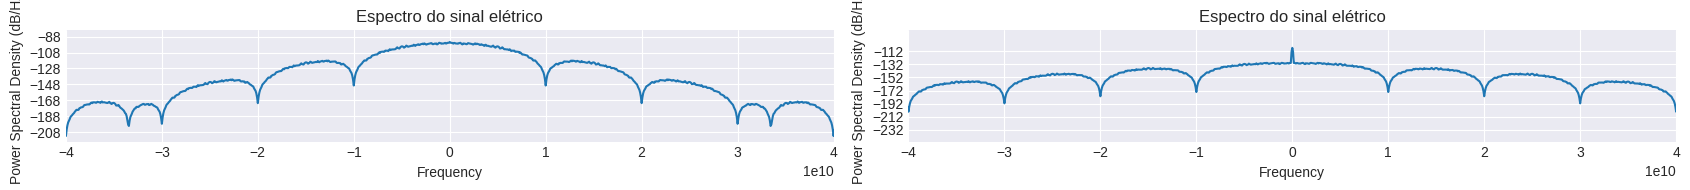

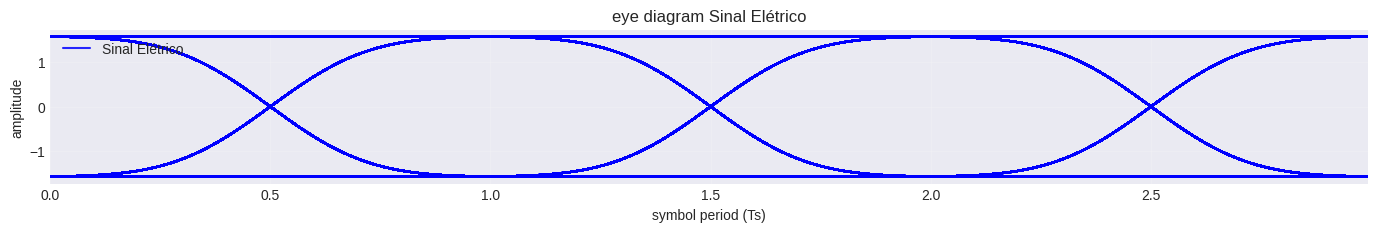

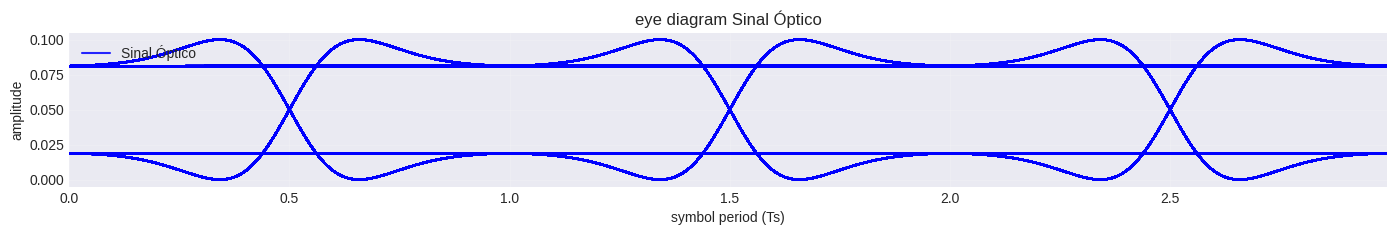

In [15]:
fig, axis = plt.subplots(1, 2, figsize=(17, 2))

axis[0].psd(sigft, Fs=Fa, NFFT = 16*1024, sides='twosided')
axis[0].set_xlim(-4*Rs, 4*Rs)
axis[0].set_ylim(-220, -80)
axis[0].set_title("Espectro do sinal elétrico")

axis[1].psd(np.abs(sigft0)**2, Fs=Fa, NFFT = 16*1024, sides='twosided')
axis[1].set_xlim(-4*Rs, 4*Rs)
axis[1].set_ylim(-250, -80)
axis[1].set_title("Espectro do sinal elétrico")

plt.tight_layout()
plt.show()

# diagrama de olho
eyediagram(sigft, sigft.size - SpS, SpS, plotlabel = "Sinal Elétrico")
eyediagram(np.abs(sigft0)**2, sigft0.size - SpS, SpS,  plotlabel = "Sinal Óptico")


Analisando as saídas, notamos que um pulso retangular na frequência gera uma sinc, que faz com que o sinal ocupe mais banda, onde no exemplo acima ocupa aproximadamente 40GHz de banda. Ao analisar um pulso cosseno levantado percebemos que ele ocupa somente uma faixa de 10GHz, isso pode ser bem útil vendo que conseguimos passar a mesma informação com menor banda. Vantagens de utilizar menor banda: menos interferência, redução da dispersão cromática e facilidadde em trabalhar com filtros limitadores de banda.

### Gerando sinais M-PAM
---

Modulação por Amplitude de Pulso (PAM), é uma forma de modulação de sinal na qual a informação da mensagem é codificada na amplitude de um trem de pulsos interrompendo a frequência portadora. Isso permite aumentar a taxa de transmissão sem aumentar a taxa de símbolos, mas pode exigir maior qualidade de canal (SNR) porque os níveis estão mais próximos. Quando transmitimos dados digitais, cada símbolo enviado pode carregar vários bits, dependendo de M:

> bits por símbolo = $log_2(M)$ \
$log_2(4) = 2 ⟶$ cada símbolo representa 2 bits






,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
bits 0,0,0,0,0,1,0,0,1,0,0,1,1,0,0,0,0,1,0,1,1
bits 1,0,1,1,0,1,0,1,1,0,0,1,0,0,1,1,0,0,1,0,1


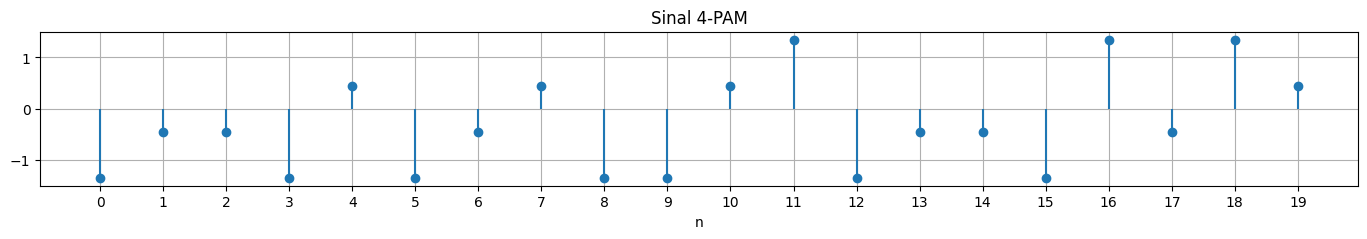

In [16]:
# parâmetros da simulação
M = 4               # ordem da modulação
constType = 'pam'   # tipo de modulação
SpS = 16            # Amostras por símbolo
Rs  = 10e9          # Taxa de símbolos
Ts  = 1/Rs          # Período de símbolo em segundos
Fa  = 1/(Ts/SpS)    # Frequência de amostragem do sinal (amostras/segundo)
Ta  = 1/Fa          # Período de amostragem

#gerando valores aleatórios de bits
bits = np.random.randint(2, size = int(20*np.log2(M)))

# Modulando o sinal
symb = modulateGray(bits, M, constType)
symb = pnorm(symb)

df = pd.DataFrame()
for n in range(int(np.log2(M))):
  df["bits "+ str(n)] = bits[n::int(np.log2(M))]

display(df.T)

plt.style.use("default")
plt.figure(figsize=(17, 2))
plt.stem(symb, basefmt=" ")
plt.xlabel("n")
plt.title("Sinal 4-PAM")
plt.xticks(np.arange(0, symb.size))
plt.ylim(-1.5, 1.5)
plt.grid()
plt.show()

In [17]:
#Ajustando para fazer usar o sinal no modulador MZM
# Aumentando a amostragem do sinal
symbolsUp = upsample(symb, SpS)
t1 = (0.5 + np.arange(0, symb.size))*(Ts/1e-12)

#Gerando pulso NRZ
paramPulse              = parameters()
paramPulse.pulseType    = "nrz"
paramPulse.SpS          = SpS

# pulso retangular ideal
pulse = pulseShape(paramPulse)
pulse = pnorm(pulse)

# Formatação pelo pulso NRZ
sigft = firFilter(pulse, symbolsUp)
sigft = sigft.real
sigft = sigft/max(np.abs(sigft))
t2 = np.arange(0, sigft.size)*(Ta/1e-12)        # Tempo em picosegundos.

#Ajustanto os pontos de amostragem
symbolsUp = symbolsUp/np.max(np.abs(symbolsUp))
symbolsUp[symbolsUp==0] = np.nan

#Modulação óptica
Po = 100e-3 # potência da portadora CW na entrada no MZM
Ai = np.sqrt(Po)
sigft0 = mzm(Ai, (-paramMZM.Vb)*sigft, paramMZM)
t3 = np.arange(0, sigft0.size)*(Ta/1e-12)

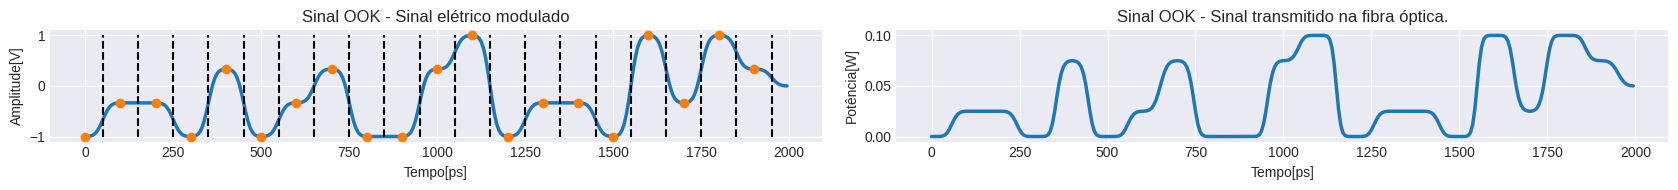

In [18]:
plt.style.use("seaborn-v0_8-darkgrid")
fig, axis = plt.subplots(1, 2, figsize=(17, 2))

axis[0].plot(t2, sigft,"-", linewidth = 2.5)
axis[0].plot(t2, symbolsUp, "o", linewidth = 2.5)
axis[0].vlines(t1, -1, 1, linestyles='dashed', color = 'k')
axis[0].set_xlabel("Tempo[ps]")
axis[0].set_ylabel("Amplitude[V]")
axis[0].set_title("Sinal OOK - Sinal elétrico modulado")

axis[1].plot(t3, np.abs(sigft0)**2, linewidth = 2.5, label = "|sigft0|²")
axis[1].set_xlabel("Tempo[ps]")
axis[1].set_ylabel("Potência[W]")
axis[1].set_title("Sinal OOK - Sinal transmitido na fibra óptica.")

plt.tight_layout()
plt.show()

In [19]:
# parâmetros da simulação
M = 4               # ordem da modulação
constType = 'pam'   # tipo de modulação
SpS = 16            # Amostras por símbolo
Rs  = 10e9          # Taxa de símbolos
Ts = 1/Rs           # Período de símbolo em segundos
Fa  = 1/(Ts/SpS)    # Frequência de amostragem do sinal (amostras/segundo)
Ta  = 1/Fa          # Período de amostragem

# Gerando valores aleatórios de bits
bits = np.random.randint(2, size = int(10e4*np.log2(M)))

# Modulando o sinal
symb = modulateGray(bits, M, constType)
symb = pnorm(symb)

# Aumentado as amostras do sinal
symbolsUp = upsample(symb, SpS)

# Gerando um pulso pulso senoidal
#Gerando pulso NRZ
paramPulse              = parameters()
paramPulse.pulseType    = "nrz"
paramPulse.SpS          = SpS

# pulso retangular ideal
pulse = pulseShape(paramPulse)
pulse = pnorm(pulse)

# Formatação pelo pulso NRZ
sigft = firFilter(pulse, symbolsUp)
sigft = sigft.real
sigft = sigft/max(np.abs(sigft))

#Ajustanto os pontos de amostragem
symbolsUp = symbolsUp/np.max(np.abs(symbolsUp))
symbolsUp[symbolsUp==0] = np.nan

#Ajustando os parametros da moduladora
Po = 100e-3 # potência da portadora CW na entrada no MZM
Ai = np.sqrt(Po)
sigft0 = mzm(Ai, (-paramMZM.Vb)*sigft, paramMZM)

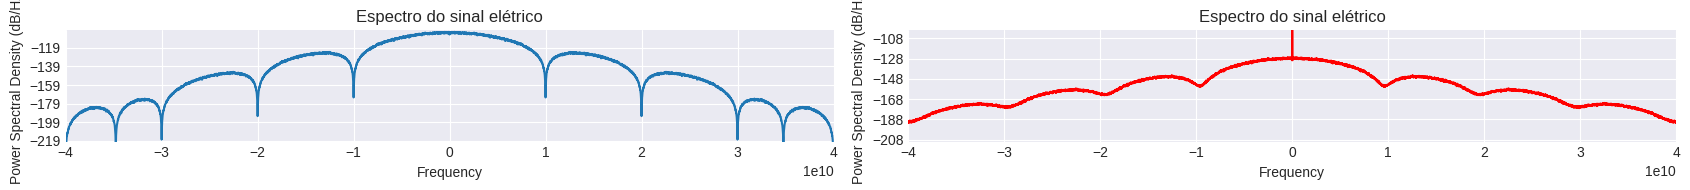

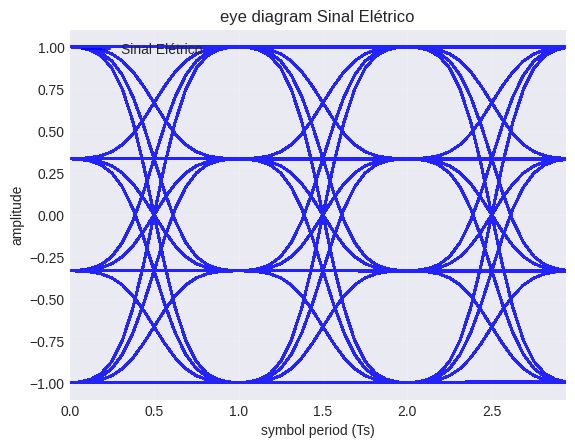

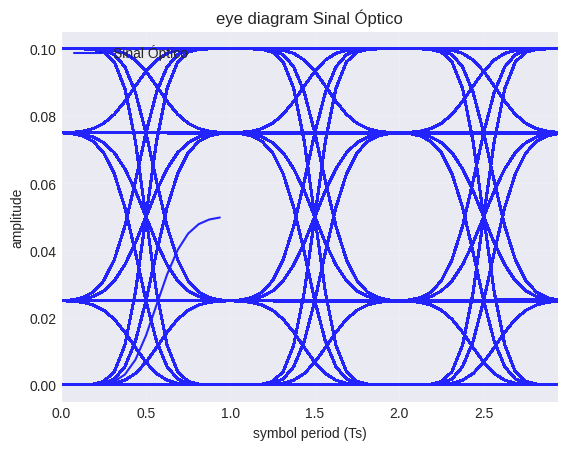

In [20]:
plt.style.use("seaborn-v0_8-darkgrid")
fig, axis = plt.subplots(1, 2, figsize=(17, 2))

axis[0].psd(sigft, Fs=Fa, NFFT = 16*1024, sides='twosided')
axis[0].set_xlim(-4*Rs, 4*Rs)
axis[0].set_ylim(-220, -100)
axis[0].set_title("Espectro do sinal elétrico")

axis[1].psd(np.abs(sigft0)**2, Fs=Fa, NFFT = 16*1024, sides='twosided', color = 'r')
axis[1].set_xlim(-4*Rs, 4*Rs)
axis[1].set_ylim(-210, -100)
axis[1].set_title("Espectro do sinal elétrico")

plt.tight_layout()
plt.show()

eyediagram(sigft, sigft.size - SpS, SpS, plotlabel = "Sinal Elétrico")
eyediagram(np.abs(sigft0)**2, sigft.size, SpS,  plotlabel = "Sinal Óptico")

### Conclusão

O sinal 4-PAM apresenta uma distorção perceptível tanto na análise espectral quanto no diagrama de olho. No espectro, a saída do sinal óptico não se assemelha bem a uma sinc, onde ter um comportamento da sinc seria o ideal. Já no diagrama de olho, essa distorção se manifesta por uma menor abertura entre os níveis intermediários, especialmente entre os níveis 1 e 2, e entre os níveis 3 e 4. Essa aproximação entre níveis dificulta a correta detecção no receptor, podendo levar à confusão entre símbolos adjacentes — algo que não ocorre com tanta intensidade no caso do sinal com apenas dois níveis (modulação binária), onde os olhos se mantêm bem definidos.

Essa dificuldade de separação entre níveis na saída do modulador óptico pode ser consequência da não linearidade da curva de transferência do MZM, somada ao fato de que sinais multíníveis são mais sensíveis a variações de amplitude e ruído. Uma possível solução seria reduzir a amplitude do sinal de entrada, evitando que os níveis fiquem em regiões mais não lineares da curva do MZM. No entanto, isso também reduziria o fator de extinção, prejudicando a razão entre os níveis lógico-alto e lógico-baixo, o que pode não ser viável em termos de desempenho óptico.

### Modulação QAM
---

A modulação QAM (Quadrature Amplitude Modulation) é uma técnica de modulação digital que representa símbolos como combinações de fase e amplitude, distribuídas no plano complexo (constelação). Cada símbolo QAM é definido por um ponto com coordenadas $I (in-phase)$ e $Q (quadrature)$, codificando múltiplos bits por símbolo.

Quando implementado opticamente, um sinal QAM pode ser gerado utilizando um modulador Mach-Zehnder paralelo em malha dupla $(Dual-Parallel.MZM)$. Esse arranjo permite controlar separadamente dois caminhos ópticos:

 - Um modulador para a componente em fase $(I)$

 - Outro modulador com defasagem de 90 graus $(π/2 rad)$ para gerar a componente em quadratura $(Q)$

Essa defasagem faz com que as duas saídas moduladas estejam ortogonais em fase — como seno e cosseno — exatamente como no QAM tradicional. A soma coerente dessas duas componentes permite formar qualquer ponto da constelação QAM desejada.

<center><img src="https://github.com/Medupl/CoppeliaSim/blob/main/images/Optic/QAM.png?raw=true" width="50%"/></center>

$$\text{Fonte: Anotações do professor Edson}$$

In [22]:
from optic.models.devices import iqm

# parâmetros da simulação
M = 16              # ordem da modulação
constType = 'qam'   # tipo de modulação
SpS = 16            # Amostras por símbolo
Rs  = 10e9          # Taxa de símbolos
Ts = 1/Rs           # Período de símbolo em segundos
Fa  = 1/(Ts/SpS)    # Frequência de amostragem do sinal (amostras/segundo)
Ta  = 1/Fa          # Período de amostragem

# gerando uma amostra aleatoria de bits, modulando e aumentando a amostra
bits = np.random.randint(2, size = int(20e4*np.log2(M)))
symb = modulateGray(bits, M, constType)
symb = symb/np.max(np.abs(symb.real))
symbolsUp = upsample(symb, SpS)

# pulso NRZ típico e filtrando
paramPulse              = parameters()
paramPulse.pulseType    = "nrz"
paramPulse.SpS          = SpS

# pulso retangular ideal
pulse = pulseShape(paramPulse)
pulse = pnorm(pulse)
sigft = firFilter(pulse, symbolsUp)
sigft = sigft/np.max(np.abs(sigft.real))

# modulação óptica
paramIQM = parameters()
paramIQM.Vpi = 2
paramIQM.Vb = -paramIQM.Vpi         # Vb = - VPi por atuar no campo elétrico.
P0 = 100e-3                         # potência da portadora CW na entrada no MZM
Ai = np.sqrt(P0)
sigft0 = iqm(Ai, 0.5*paramIQM.Vpi*sigft, paramIQM)

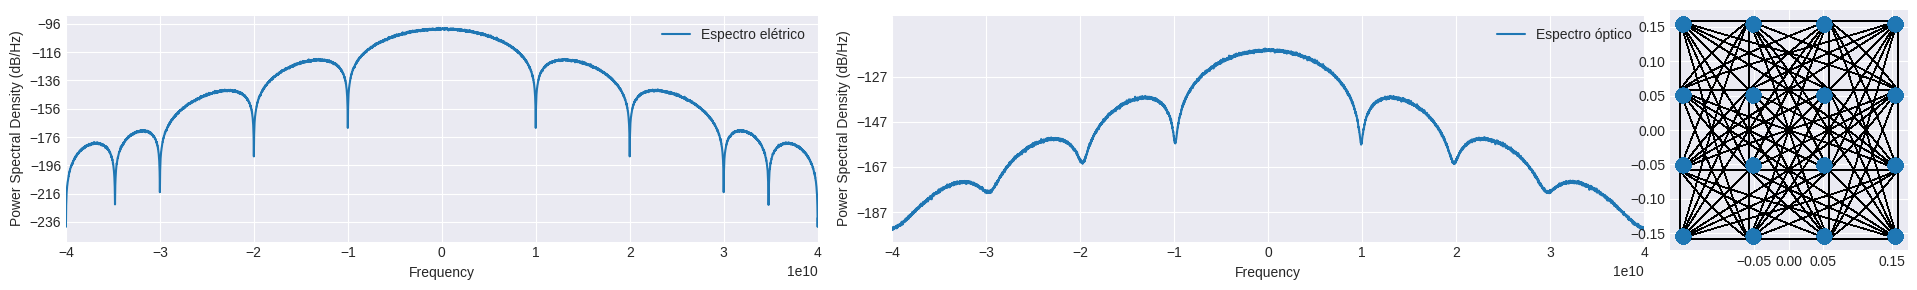

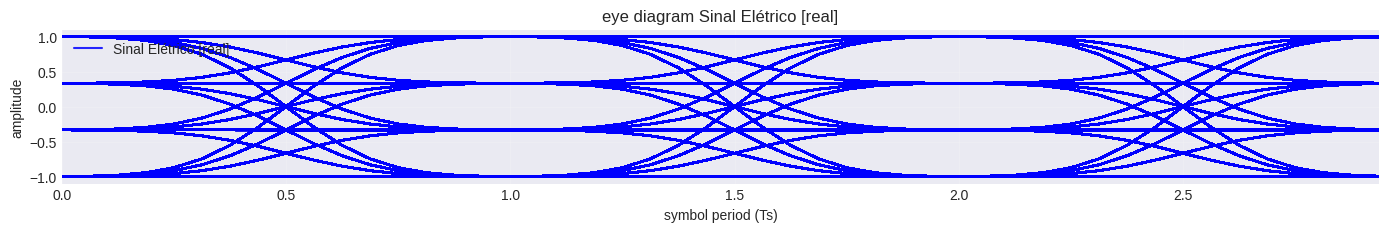

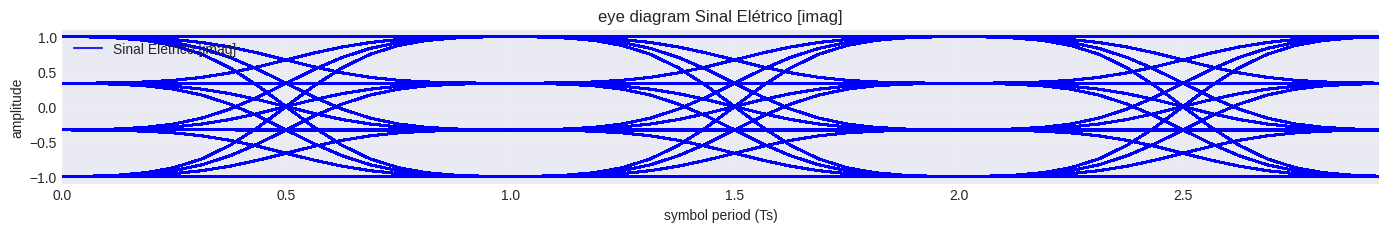

In [26]:
plt.style.use("seaborn-v0_8-darkgrid")
fig, axis = plt.subplots(1, 3, figsize=(25, 3))

# plotando a densidade espectral do sinal
axis[0].psd(sigft,Fs=Fa, NFFT = 16*1024, sides="twosided", label = "Espectro elétrico")
axis[0].set_xlim(-4*Rs,4*Rs)
axis[0].set_ylim(-250,-90)
axis[0].legend(loc="best")

axis[1].psd(sigft0, Fs=Fa, NFFT = 16*1024, sides="twosided", label = "Espectro óptico")
axis[1].set_xlim(-4*Rs,4*Rs)
axis[1].set_ylim(-200,-100)
axis[1].legend(loc="best")
plt.tight_layout()

# plotando a constelação da modulação QAM
axis[2].plot(sigft0.real,sigft0.imag,"k--", linewidth=0.5)
axis[2].plot(np.sqrt(signalPower(sigft0))*symb.real, np.sqrt(signalPower(sigft0))*symb.imag,"o", markersize=10)
axis[2].set_position([0.67, 0.15, 0.095, 0.8])
axis[2].set_xticks([-0.75, -0.05, 0, 0.05, 0.15])
axis[2].axis("equal")

# plotando o diagrama de olho
eyediagram(sigft, sigft.size - SpS, SpS, plotlabel = "Sinal Elétrico", ptype = "fast")

plt.show()

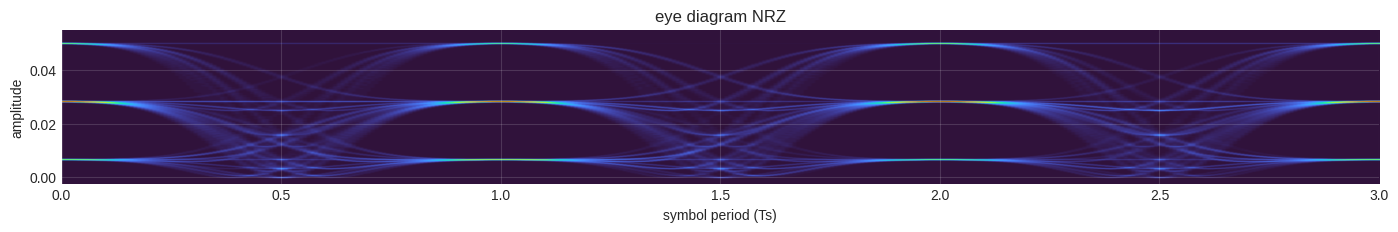

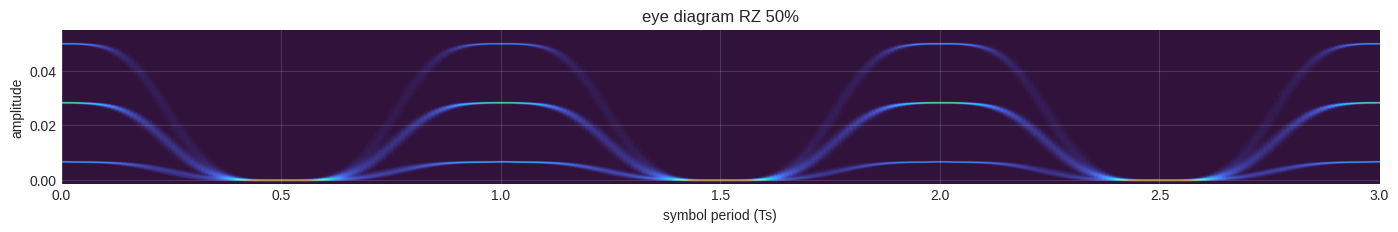

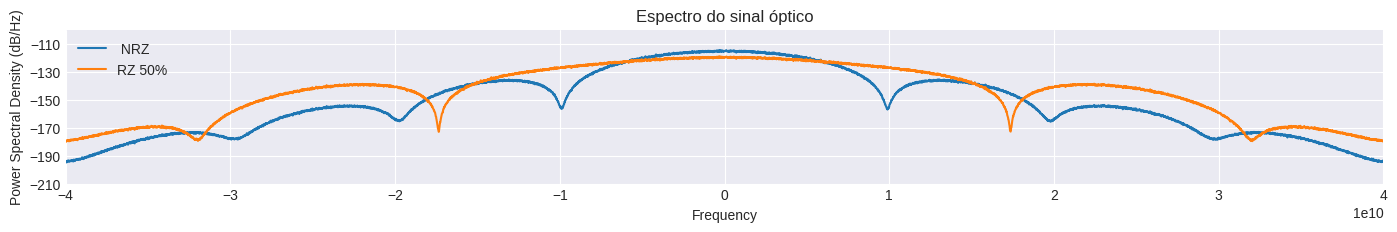

In [27]:
# Pulsos RZ 50%: Vb = Vπ/2, Vs = Vπ/2, fs = Rs,   ϕs = π
# Pulsos RZ 33%: Vb = 0,    Vs = Vπ,   fs = Rs/2, ϕs = π/2
# Pulsos RZ 67%: Vb = Vπ,   Vs = Vπ,   fs = Rs/2, ϕs = 0

SpS = 16         # Amostras por símbolo
Rs  = 10e9       # Taxa de símbolos
Ts  = 1/Rs       # Período de símbolo em segundos
Fa  = SpS*Rs     # Frequência de amostragem do sinal (amostras/segundo)
Ta  = 1/Fa       # Período de amostragem
RZ = 50
t = np.arange(0, sigft0.shape[0])*Ta

# parâmetros do MZM
paramMZM = parameters()
paramMZM.Vpi = 2
Ai = 1

# parâmetros do formatador para cada tipo de pulso RZ
if RZ == 33:

    paramMZM.Vb = 0
    # parâmetros do sinal senoidal
    fs = Rs/2
    Vs = paramMZM.Vpi
    ϕs = np.pi/2

elif RZ == 50:

    paramMZM.Vb = paramMZM.Vpi/2
    # parâmetros do sinal senoidal
    fs = Rs
    Vs = paramMZM.Vpi/2
    ϕs = np.pi

elif RZ == 67:

    Vb = paramMZM.Vpi
    # parâmetros do sinal senoidal
    fs = Rs/2
    Vs = paramMZM.Vpi
    ϕs = 0

# gera sinal senoidal
senoideRF = Vs*np.cos(2*np.pi*fs*t + ϕs)

# MZM utilizado como formatador de pulso (pulse carver)
sigft02 = mzm(sigft0, senoideRF, paramMZM)

# diagramas de olho
eyediagram(np.abs(sigft0)**2,sigft0.size-SpS, SpS, plotlabel='NRZ', ptype='fancy')
eyediagram(np.abs(sigft02)**2, sigft0.size-SpS, SpS, plotlabel='RZ '+str(RZ)+'%', ptype='fancy')

# plota psd
plt.figure();
plt.xlim(-4*Rs,4*Rs);
plt.ylim(-210,-100);
plt.title('Espectro do sinal óptico')
plt.psd(sigft0,Fs=Fa, NFFT = 16*1024, sides='twosided', label = ' NRZ')
plt.psd(sigft02,Fs=Fa, NFFT = 16*1024, sides='twosided', label = 'RZ '+str(RZ)+'%')
plt.legend(loc='upper left');

### Análise comparativa entre o sinal QAM e o sinal 4-PAM
---

Analisando o espectro e o diagrama de olho, observa-se que o sinal QAM apresenta um desempenho superior ao do sinal 4-PAM. No domínio da frequência, o espectro do sinal QAM se aproxima mais de uma forma de sinc ideal, o que é esperado de um sinal com boa conformação espectral e filtragem adequada.

Ao comparar os diagramas de olho, especialmente do sinal óptico na saída do modulador, nota-se que o sinal QAM, por conter componentes em fase (I) e em quadratura (Q), promove uma transição mais precisa entre os níveis, resultando em maior separação e definição dos olhos. Essa característica contribui para uma melhor razão de extinção e maior imunidade a ruídos ou distorções de amplitude, quando comparado ao sinal 4-PAM, cujos níveis mais próximos podem facilmente se sobrepor devido à resposta não linear do modulador óptico.
  - $PAM$ é simples, direto e modula a potência da luz — ótimo para sistemas de intensidade direta.
  - $QAM$ é mais complexo, mas muito mais eficiente, porque modula o campo elétrico óptico — exigindo transmissão e detecção coerente.



### Referências
---

1. **OpticalCommunications**. *Edson porto da Silva*. Disponível em: [https://github.com/edsonportosilva/OpticalCommunications/...notebooks](https://github.com/edsonportosilva/OpticalCommunications/tree/main/jupyter%20notebooks). Acessado em: 28 de abril de 2025.